In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style='whitegrid',palette='muted',font_scale=1.05)
pd.set_option('display.max_columns',200)

In [9]:
df=pd.read_csv('C:/Users/admin/Desktop/customer-churn-prediction\Churn_Modelling .csv')
print('Shape:',df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
#info& Summarry
display(df.info())
display(df.describe(include='all'), True)

#missing values

print('\nMissing values per column:')
print(df.isnull().sum())

#target distribution

print('\nChurn value counts:')
print(df['Exited'].value_counts(normalize=False))
print('\nChurn prportion:' )
print(df['Exited'].value_counts(normalize=True))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


None

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


True


Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Churn value counts:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn prportion:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [11]:
#visualisation
df.dtypes



RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

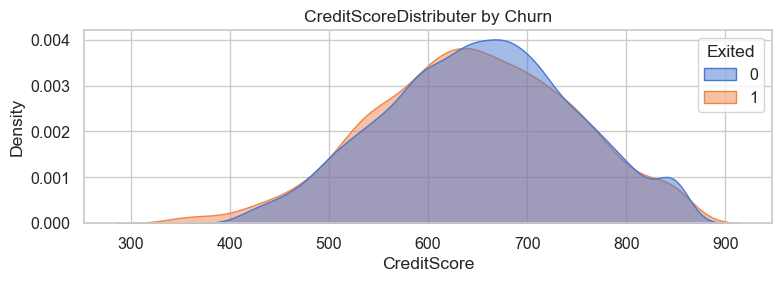

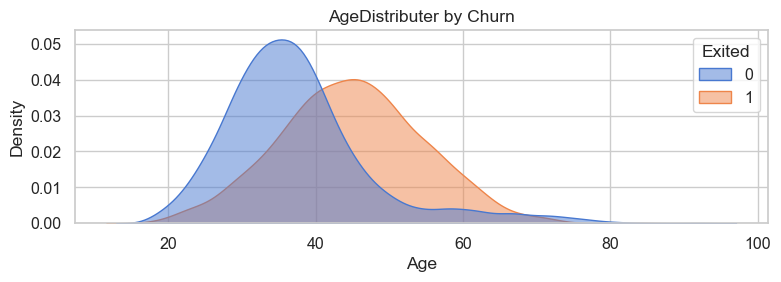

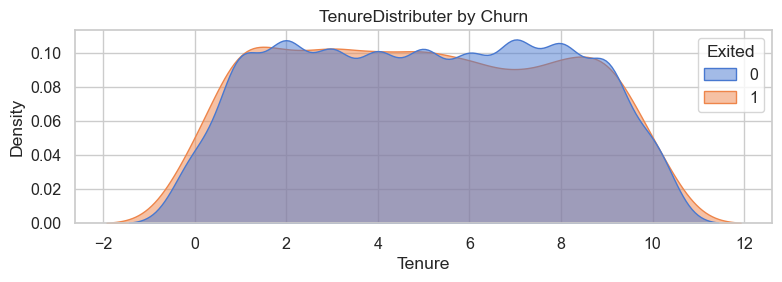

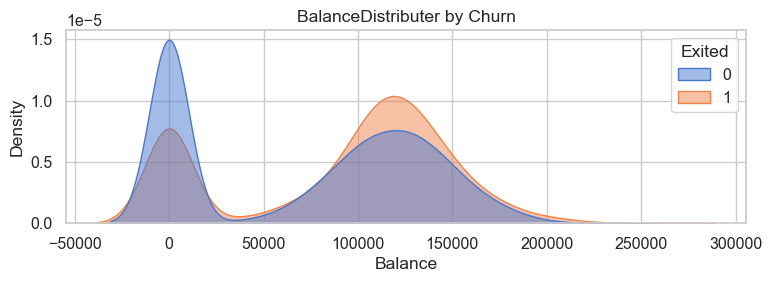

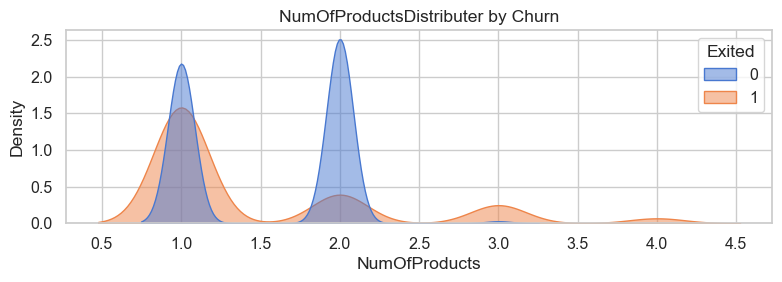

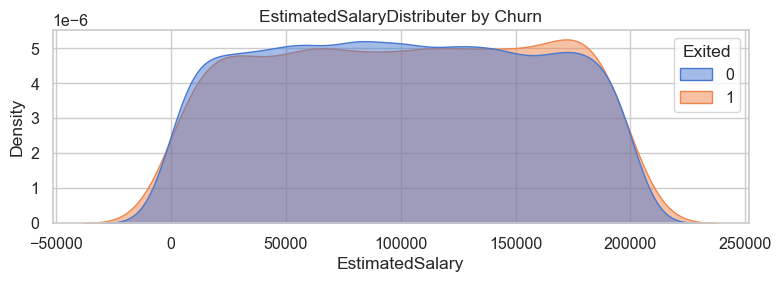

In [12]:
num_cols=['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']

for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.kdeplot(data=df, x=col,hue='Exited', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'{col}Distributer by Churn')
    plt.tight_layout()
    plt.show()

Text(0.5, 1.02, 'Pairwise Relationship Among Key  Numeric Features')

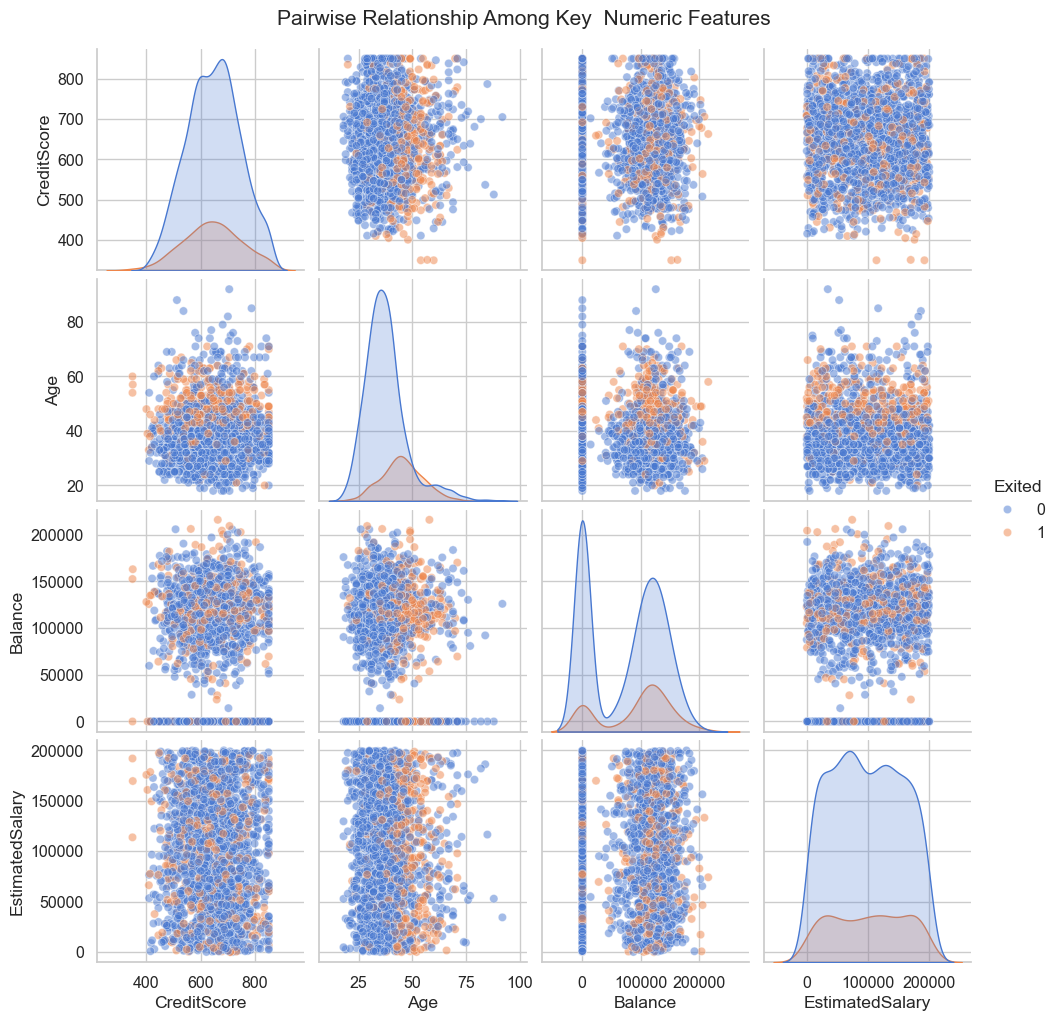

In [13]:
#pairplot
sns.pairplot(df.sample(frac=0.2,random_state=42),
             vars=['CreditScore','Age','Balance','EstimatedSalary'],
             hue='Exited',diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pairwise Relationship Among Key  Numeric Features',y=1.02)

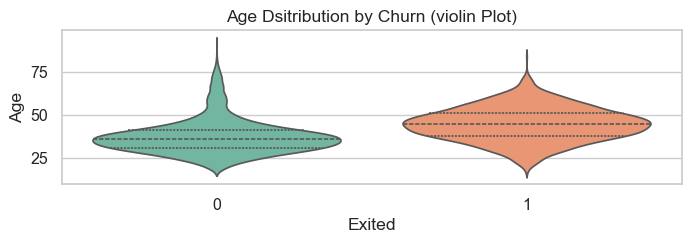

In [14]:
#violin plot
plt.figure(figsize=(8,2))
sns.violinplot(data=df, x='Exited', y='Age', inner='quart',palette='Set2')
plt.title('Age Dsitribution by Churn (violin Plot)')
plt.show()

Text(0.5, 1.0, 'Tenure Distance by Churn')

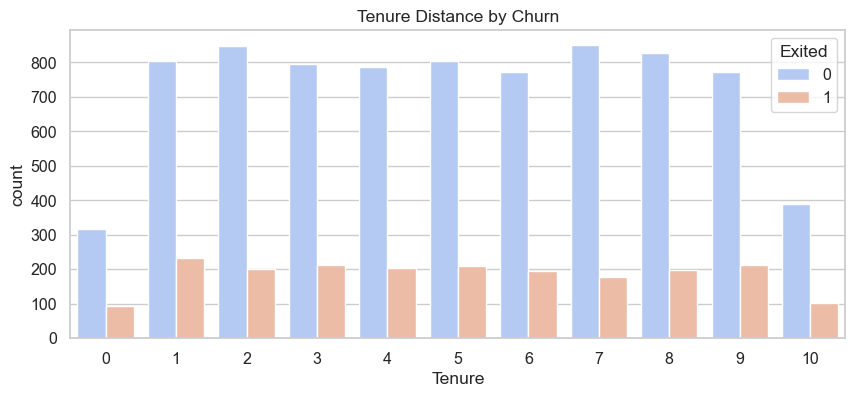

In [15]:
#tennure distance

plt.figure(figsize=(10,4))
sns.countplot(data=df, x='Tenure', hue='Exited', palette='coolwarm')
plt.title('Tenure Distance by Churn')

In [16]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

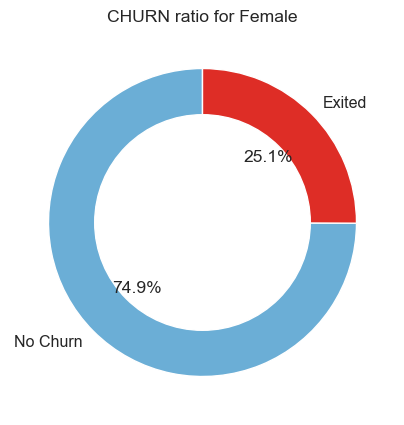

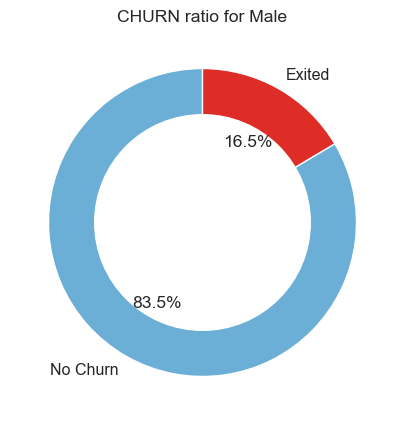

In [17]:
#gender vs churn by donut chart 

Gender_counts=df.groupby('Gender')['Exited'].value_counts(normalize=True).unstack().fillna(0)
for Gender in Gender_counts.index:
    plt.figure(figsize=(5,5))
    plt.pie(Gender_counts.loc[Gender], labels=['No Churn','Exited'],
            autopct='%1.1f%%', startangle=90, colors=['#6baed6','#de2d26'])
    center = plt.Circle((0,0),0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(center)
    plt.title(f'CHURN ratio for {Gender}')

In [18]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [19]:
#categorical features
df.drop(['RowNumber','Surname'],axis=1,inplace=True)

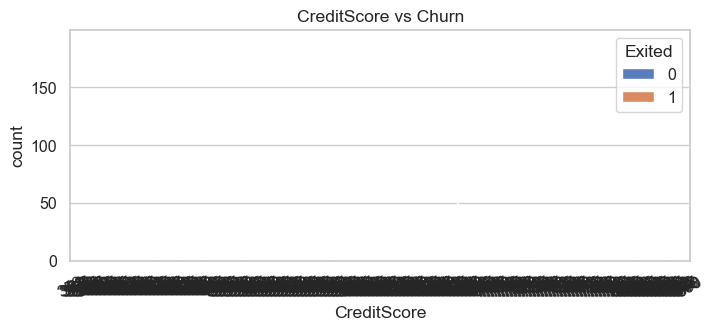

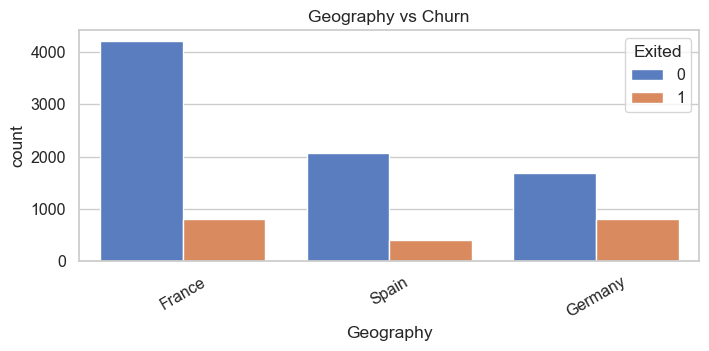

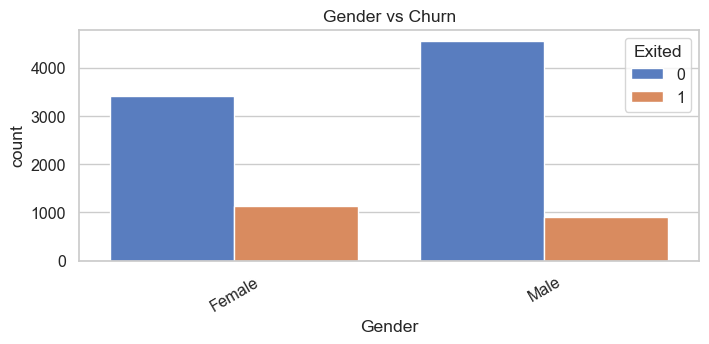

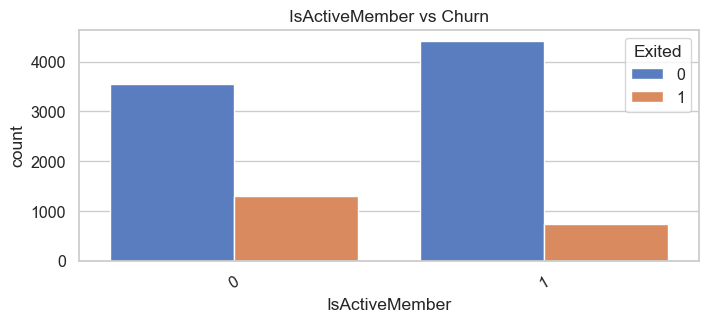

In [20]:
cat_cols=['CreditScore','Geography','Gender','IsActiveMember']
for c in cat_cols:
    plt.figure(figsize=(8,3))
    sns.countplot(data=df,x=c,hue='Exited')
    plt.title(f'{c} vs Churn')
    plt.xticks(rotation=30)

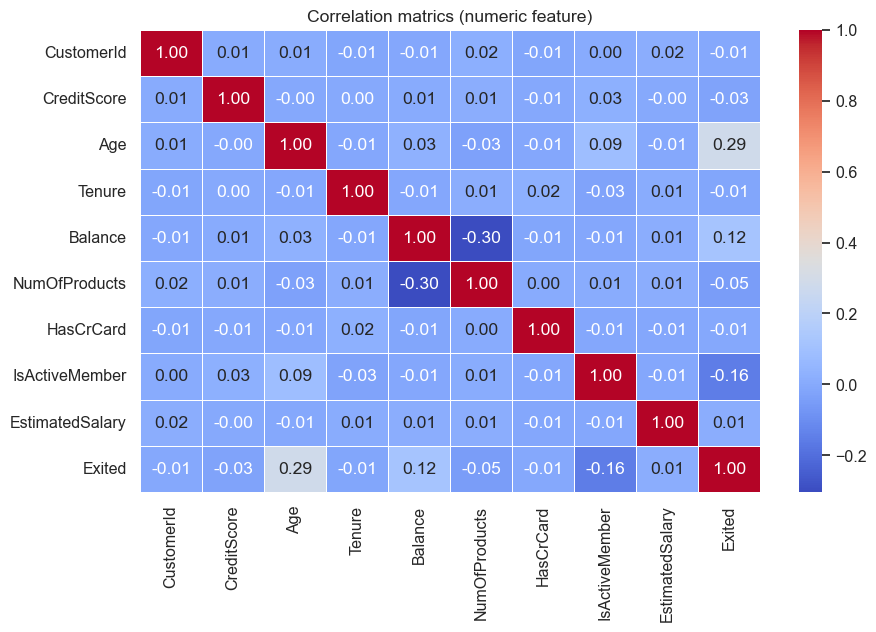

In [21]:
#heatmap 
plt.figure(figsize=(10,6))
corre=df.corr(numeric_only=True)
sns.heatmap(corre, annot=True, fmt='.2f', cmap='coolwarm',linewidths=0.5)
plt.title('Correlation matrics (numeric feature)')
plt.show()

In [22]:
numeric_data=df[num_cols]#use the numeric columns from your feature-engineererd dataframe
corr = numeric_data.corr()
corr.style.background_gradient(cmap='coolwarm')

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000


Text(0.5, 1.0, 'Balance vs Number of Products by Churn')

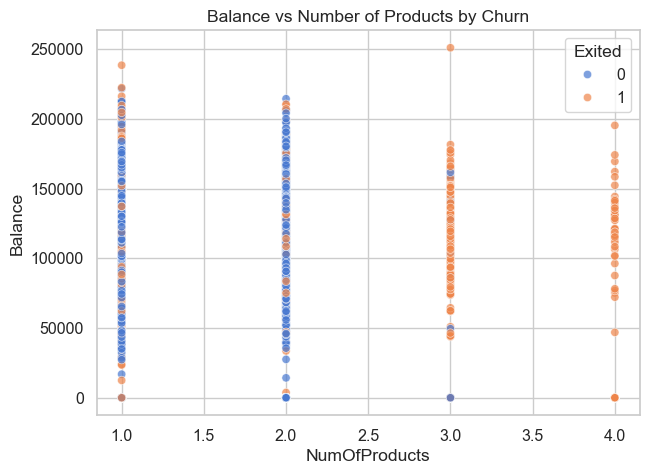

In [23]:
#balance vs product scatter 
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='NumOfProducts',y='Balance',hue='Exited',alpha=0.7)
plt.title('Balance vs Number of Products by Churn')

Text(0.5, 1.0, 'Churn rate vs Number Of Products')

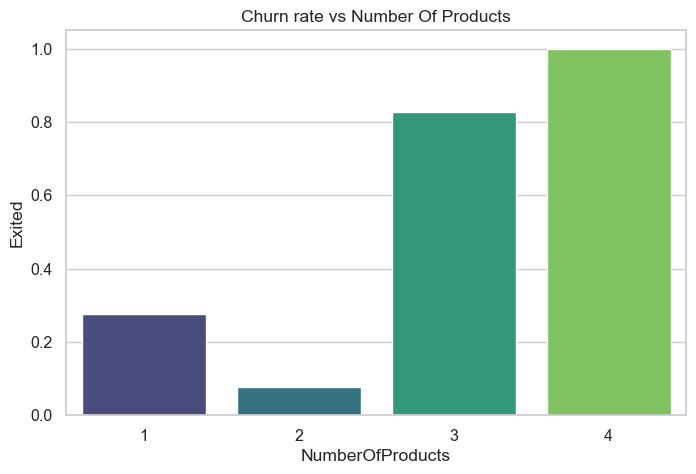

In [24]:
#aggregate churn rate per number products
churn_rate=df.groupby('NumOfProducts')['Exited'].mean().reset_index()
#plot churn rate
plt.figure(figsize=(8,5))
sns.barplot(data=churn_rate, x='NumOfProducts', y='Exited',palette='viridis')
plt.xlabel('NumberOfProducts')
plt.ylabel=('Exited')
plt.title('Churn rate vs Number Of Products')

In [25]:
#feature engineering

#create meaningfull Features: eg balance perproduct,age group,salsry bracket,and handle missing value 


In [26]:
df_fe=df.copy()
#balance per product
df_fe['balance per product'] =df_fe['Balance'] / (df_fe['NumOfProducts'].replace(0,np.nan))
df_fe['balance per product'].fillna(0, inplace=True)
#salary to balance ratio
df_fe['salary_balance_ratio']=df_fe['EstimatedSalary'] /(df_fe['Balance'].replace(0, np.nan))
df_fe['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan,inplace=True)
df_fe['salary_balance_ratio'].fillna(df_fe['salary_balance_ratio'].median(),inplace=True)

#Age group
bins=[0,25,35,45,55,65,100]
labels=['<25','25-31','35-44','45-54','55-64','65+']
df_fe['age_group']=pd.cut(df_fe['Age'], bins=bins,labels=labels)

#tenure bucket

df_fe['tenure_buckets']=pd.cut(df_fe['Tenure'],bins=[-1,0,2,5,10,100],labels=['0','1-2','3-5','6-10','10+'])

#flage high balance
df_fe['high_balance']=(df_fe['Balance']>df_fe['Balance'].quantile(0.75)).astype(int)

#quick checks
df_fe[['balance per product','salary_balance_ratio','Age','age_group','Tenure','tenure_buckets','high_balance']].head()

,balance per product,salary_balance_ratio,Age,age_group,Tenure,tenure_buckets,high_balance
0,0.000000,0.839258,42,35-44,2,1-2,0
1,83807.860000,1.342864,41,35-44,1,1-2,0
2,53220.266667,0.713585,42,35-44,8,6-10,1
3,0.000000,0.839258,39,35-44,1,1-2,0
4,125510.820000,0.630098,43,35-44,2,1-2,0


In [27]:
#preprocessing & encoding

df_fe.isna().sum()

CustomerId              0
CreditScore             0
Geography               0
Gender                  0
Age                     0
Tenure                  0
Balance                 0
NumOfProducts           0
HasCrCard               0
IsActiveMember          0
EstimatedSalary         0
Exited                  0
balance per product     0
salary_balance_ratio    0
age_group               0
tenure_buckets          0
high_balance            0
dtype: int64

In [28]:
target='Exited'
drop_cols=['CustomerId']
feature=[c for c in df_fe.columns if c not in [target]+ drop_cols]

numeric_features=['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary',
                  'balance per product','salary_balance_ratio']
categorical_Features=['Geography','Gender','HasCrCard','IsActiveMember','age_group','tenure_buckets','high_balance']

df_fe[categorical_Features]=df_fe[categorical_Features].astype('object')

numeric_transformer=Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

categorical_transformer=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor=ColumnTransformer([
    ('num',numeric_transformer,numeric_features),
    ('cat',categorical_transformer,categorical_Features)
])

print('Numeric Feature:',numeric_features)
print('categorical_Features',categorical_Features)

Numeric Feature: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'balance per product', 'salary_balance_ratio']
categorical_Features ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'age_group', 'tenure_buckets', 'high_balance']


In [29]:
#train test Split

x=df_fe[feature]
y=df_fe[target]

x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
print('Train shape:',x_train.shape,'Test shape:',x_test.shape)
print('Train Churn propotion:',y_train.mean(),'Test churn propotion:',y_test.mean())

Train shape: (8000, 15) Test shape: (2000, 15)
Train Churn propotion: 0.20375 Test churn propotion: 0.2035


In [30]:
#train multiple model with a pipeline and compar eusing cross -validation


In [31]:
models={
    'LogisticRegression':LogisticRegression(max_iter=500),
    'RandomForest':RandomForestClassifier(n_estimators=200,random_state=42),
    'GradientBoosting':GradientBoostingClassifier(n_estimators=200,random_state=42),
    'AdaBoost':AdaBoostClassifier(n_estimators=200,random_state=42),
    'SVC':SVC(probability=True,random_state=42)
}
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
results={}

for name, model in models.items():
    pip=Pipeline(steps=[('prepocessor',preprocessor),
                        ('classifier',model)])
    score=cross_val_score(pip,x_train,y_train,cv=cv,scoring='roc_auc',n_jobs=-1)
    results[name]=score
    print(f'{name} AUC: Mean={score.mean():4f} Std={score.std():4f}')


LogisticRegression AUC: Mean=0.787750 Std=0.024396
RandomForest AUC: Mean=0.848597 Std=0.013049
GradientBoosting AUC: Mean=0.862778 Std=0.009688
AdaBoost AUC: Mean=0.846153 Std=0.013346
SVC AUC: Mean=0.835128 Std=0.010412


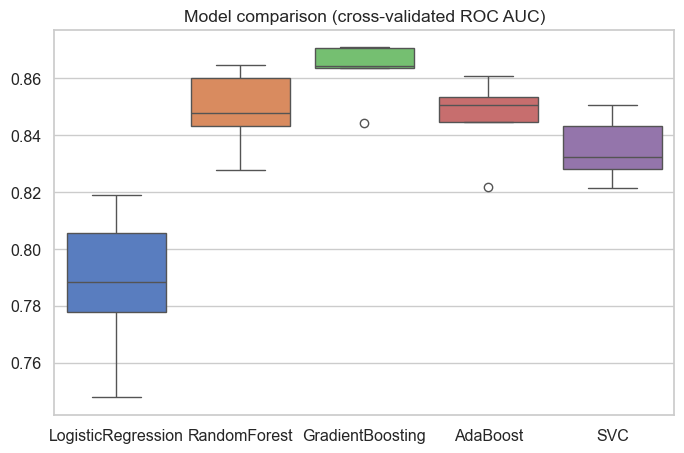

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(data=[results[m] for m in results.keys()])
plt.xticks(ticks=range(len(results)), labels=list(results.keys()))

plt.title('Model comparison (cross-validated ROC AUC)')
plt.show()


In [33]:
#fit best model

In [34]:
best_name=max(results.keys(),key=lambda k: results[k].mean())
best_name,results[best_name].mean()

('GradientBoosting', np.float64(0.8627777349731776))

Test Accuracy: {acc:.4f}
Test Precision: {prec:.4f}
Test Recall:{rec:.4f}
Test F1-score:{f1:.4f}
Test ROC AU:{roc:.4f}

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



TypeError: 'str' object is not callable

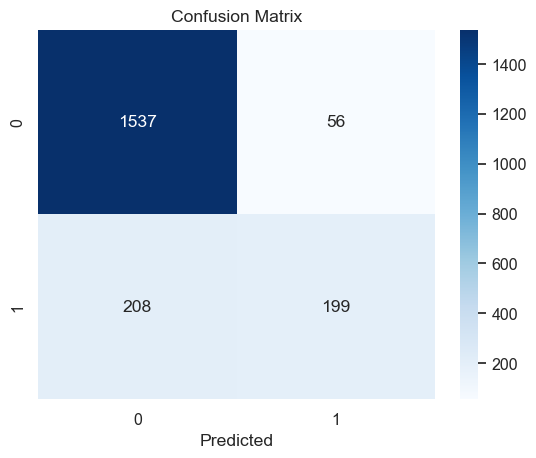

In [35]:
best_model=models[best_name]
best_pipeline=Pipeline(steps=[('preprocessor',preprocessor),
                              ('classifier', best_model)])
best_pipeline.fit(x_train,y_train)

y_pred=best_pipeline.predict(x_test)
y_proba=best_pipeline.predict_proba(x_test)[:,1]

acc=accuracy_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
rec=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
roc=roc_auc_score(y_test,y_pred)

print('Test Accuracy: {acc:.4f}')
print('Test Precision: {prec:.4f}')
print('Test Recall:{rec:.4f}')
print('Test F1-score:{f1:.4f}')
print('Test ROC AU:{roc:.4f}')

print('\nClassification report:')
print(classification_report(y_test,y_pred))


cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')

plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.show()

Age                     0.327665
NumOfProducts           0.266459
balance per product     0.063396
Balance                 0.056953
IsActiveMember_0        0.052653
Geography_Germany       0.050689
IsActiveMember_1        0.047992
salary_balance_ratio    0.029992
EstimatedSalary         0.025547
CreditScore             0.022685
age_group_45-54         0.020634
age_group_55-64         0.007968
Gender_Female           0.006850
Gender_Male             0.006532
Tenure                  0.005683
Geography_France        0.003164
tenure_buckets_3-5      0.001564
age_group_35-44         0.001415
HasCrCard_1             0.000697
Geography_Spain         0.000577
dtype: float64

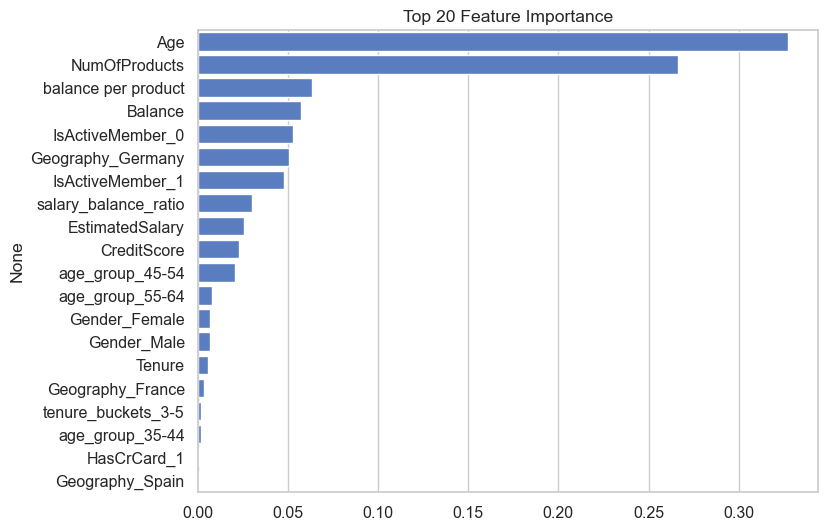

In [ ]:
if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):

    # Numeric features
    num_feats = numeric_features  # make sure this list exists

    # Categorical features from onehot encoder
    cat_feats = list(
        best_pipeline.named_steps['preprocessor']
        .transformers_[1][1]  # ColumnTransformer second transformer
        .named_steps['onehot']
        .get_feature_names_out(categorical_Features)  # check variable name
    )

    # Combine feature names
    feature_name = num_feats + list(cat_feats)

    # Feature importances
    importances = best_pipeline.named_steps['classifier'].feature_importances_

    # Top 20 features
    f1 = pd.Series(importances, index=feature_name).sort_values(ascending=False)[:20]
    display(f1)

    # Plot
    plt.figure(figsize=(8,6))
    sns.barplot(x=f1.values, y=f1.index)
    plt.title('Top 20 Feature Importance')
    plt.show()

else:
    print('Selected model does not provide feature_importances_ attribute.')
    


In [ ]:
joblib.dump(best_pipeline,'best_churn_pipeline.pk1')
print('Svaed pipline:best_churn_pipeline.pk1')

Svaed pipline:best_churn_pipeline.pk1


In [ ]:
import streamlit as st
import pandas as pd
import joblib